In [1]:
# Steel model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from resource_model import ResourceModel
from const import (CLASS_TO_REGION_DICT, REGION_TO_CLASS_DICT, 
                   path_input_data, all_regions_list_class, REGION_TO_CLASS_DICT_IMAGE_MAT)

In [2]:
# Steel
steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                       image_mat_available = True, start_year = 1971, 
                       convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                       trade_data=True)



# steel_grouping = {'all': all_regions_list_class[:-1]}

high = ['class_ 14']
low = ["class_ 3", "class_ 4", "class_ 5", "class_ 6",
       "class_ 8", "class_ 9", "class_ 17"]
       
rest = all_regions_list_class[:-1]
rest = [r for r in rest if r not in (high + low)]


steel_grouping = {'high' : high,
                  'low' : low,
                  'rest' : rest}

""" steel_grouping =     {'Canada': 'class_ 1',
    'US': 'class_ 2',
    'Mexico': 'class_ 3',
    'Rest C.Am.': 'class_ 4',
    'Brazil': 'class_ 5',
    'Rest S.Am.': 'class_ 6',
    'N.Africa': 'class_ 7',
    'W.Africa': 'class_ 8',
    'E.Africa': 'class_ 9',
    'South Africa': 'class_ 10',
    'W.Europe': 'class_ 11',
    'C.Europe': 'class_ 12',
    'Turkey': 'class_ 13',
    'Ukraine': 'class_ 14',
    'Stan': 'class_ 15',
    'Russia': 'class_ 16',
    'M.East': 'class_ 17',
    'India': 'class_ 18',
    'Korea': 'class_ 19',
    'China': 'class_ 20',
    'SE.Asia': 'class_ 21',
    'Indonesia': 'class_ 22',
    'Japan': 'class_ 23',
    'Oceania': 'class_ 24',
    'Rest S.Asia': 'class_ 25',
    'Rest S.Africa': 'class_ 26'} """

all_regions_list_class[:-1]

steel.data_grouped_regions(regions_grouping = steel_grouping)

# get drivers for fitting (regions dont need to be summed, regions dict is none)
steel.sum_IMAGE_drivers_regions(regions_dict=None)

steel.match_MAT_data_to_regions_year(match_external_regions=False)
steel.calculate_historic_other_fraction()

In [3]:
# Share of IAMGE MAT data to total consumption
share_mat_total = (steel.image_mat_data/steel.historic_consumption_data*100).mean()

In [4]:
# deal with regions where there are negative values because consumption was lower than mat projections
steel.historic_other_fraction_consumption[['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']]

# too many negative: class 4, 8, 9, 22, 25, 26
# assumption: IMAGE MATERIALS is overestimating, 
# real consumption numbers are true &  
# TODO: MATERIALS calculations should be scaled down accordingly 
neg_classes = ['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']
steel.historic_other_fraction_consumption[neg_classes] = steel.historic_consumption_data[neg_classes]

# deal with single negative numbers by removing them from dataset
steel.historic_other_fraction_consumption[steel.historic_other_fraction_consumption < 0] = np.nan


<Axes: >

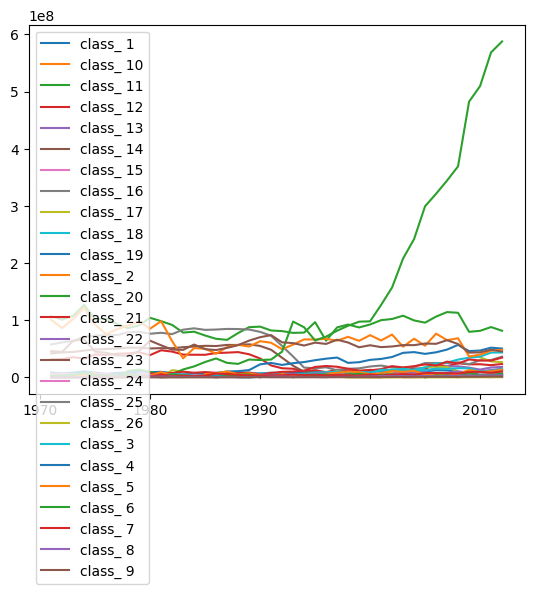

In [5]:
# Plot
steel.historic_other_fraction_consumption.plot()

In [6]:

# Fit models 
steel.calculate_regressors(steel.historic_other_fraction_consumption)
steel.fit_models()

# Best models
steel.best_rmse_models
steel.merged_rmse_r2

# project based on best model
steel.project_on_total(all_regions_list_class[:-1], 
                        REGION_TO_CLASS_DICT,
                        steel.gdp_pc_100)

high
low
Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Optimal parameters not found: Number of calls to function has reached maxfev = 800.
rest


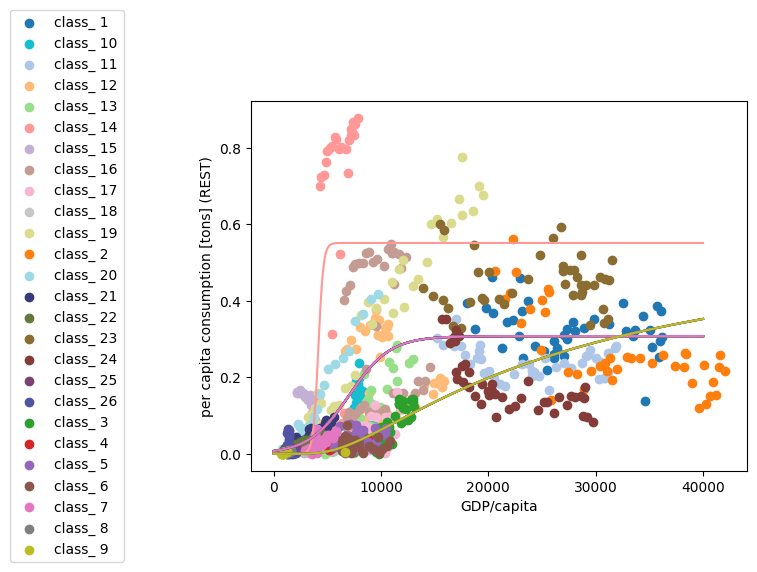

In [14]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', '#637939', '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in steel.cons_capita.columns:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
    
    ax.plot(steel.region_model_match.get(region).predict(np.arange(1, 40001).reshape(-1, 1)),
            color = color_dict.get(region))

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")



ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))

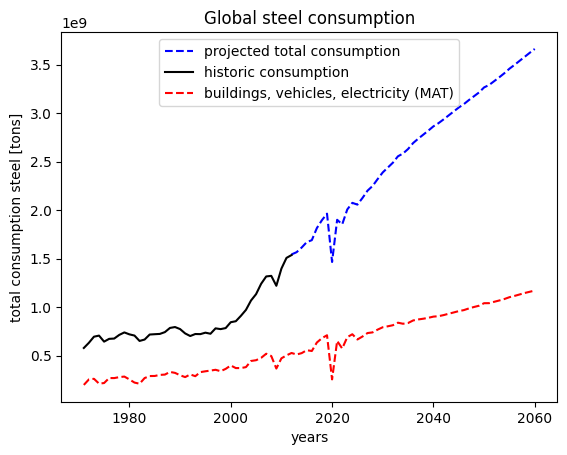

In [11]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot((steel.projection_per_region*steel.pop_100).sum(axis = 1) + steel.image_mat_data.sum(axis = 1).loc[2012:], 
        linestyle = '--', color = 'blue', label = 'projected total consumption')
ax.plot(steel.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(steel.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.set_ylabel("total consumption steel [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global steel consumption")
ax.legend(loc = 'upper center')

In [12]:
def plot_total_consumption_per_region(region):

        fig, ax = plt.subplots()             # Create a figure containing a single Axes.


        if region in neg_classes:
            print(f"Region {region} has a higher consumption in MAT than the total, so using unly historic consumption data instead of projection.")
            ax.plot((steel.projection_per_region[region]*steel.pop_100[region]), 
                    linestyle = '-', color = 'black', label = 'projected total consumption')
        else:
               ax.plot((steel.projection_per_region[region]*steel.pop_100[region]) + steel.image_mat_data[region].loc[2012:],
                       linestyle = '--', color = 'blue', label = 'projected total consumption')
        ax.plot(steel.historic_consumption_data[region],
                linestyle = '-', color = 'black', label = 'historic consumption')  

        ax.plot(steel.image_mat_data[region].loc[1971:],
                linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

        ax.set_ylabel("total consumption steel [tons]")
        ax.set_xlabel("years") 
        ax.title.set_text("Global steel consumption")
        ax.legend(loc = 'upper center')

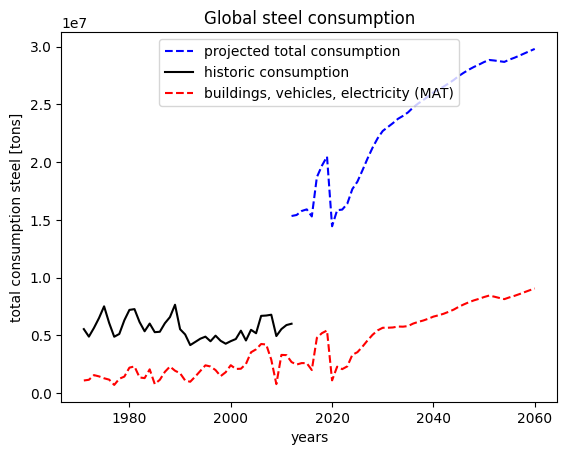

In [13]:
plot_total_consumption_per_region('class_ 10')